In [2]:
import os
from pathlib import Path
import kagglehub
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import torchvision.models as models
from torchsummary import summary
from torchmetrics import Accuracy, MeanMetric
from PIL import Image
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import mlflow
import mlflow.pytorch

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [3]:
kaggle_path = kagglehub.dataset_download("cookiefinder/tomato-disease-multiple-sources")

print("Path to dataset files:", kaggle_path)

Path to dataset files: C:\Users\hrichard\.cache\kagglehub\datasets\cookiefinder\tomato-disease-multiple-sources\versions\1


In [4]:
dataset_path = Path(kaggle_path)
dataset_path

WindowsPath('C:/Users/hrichard/.cache/kagglehub/datasets/cookiefinder/tomato-disease-multiple-sources/versions/1')

In [5]:
os.listdir(dataset_path)

['train', 'valid']

In [14]:
# Using validation set as test set for performance evaluation
train_folder_path = os.path.join(dataset_path, "train")
test_folder_path = os.path.join(dataset_path, "valid")

In [15]:
def get_dataset_info(path):
    data = []

    folder_path = Path(path)

    # Loop through subdirectories (disease classes)
    for class_dir in folder_path.iterdir():
        if class_dir.is_dir():
            label = class_dir.name
            # Loop through image files in the class directory
            for filepath in class_dir.iterdir():
                if filepath.is_file() and filepath.suffix.lower() in ['.jpg', '.jpeg', '.png']:
                    data.append({'path': str(filepath), 'label': label})

    df = pd.DataFrame(data)
    return df

In [16]:
train_dataset = get_dataset_info(train_folder_path)
print("Train dataset:\n\n", train_dataset["label"].value_counts())

Train dataset:

 label
Late_blight                             3113
healthy                                 3051
Septoria_leaf_spot                      2882
Bacterial_spot                          2826
Leaf_Mold                               2754
Early_blight                            2455
Tomato_mosaic_virus                     2153
Tomato_Yellow_Leaf_Curl_Virus           2039
Target_Spot                             1827
Spider_mites Two-spotted_spider_mite    1747
powdery_mildew                          1004
Name: count, dtype: int64


In [17]:
test_df = get_dataset_info(test_folder_path)
print("Test dataset:\n\n", test_df["label"].value_counts())

Test dataset:

 label
healthy                                 806
Late_blight                             792
Septoria_leaf_spot                      746
Leaf_Mold                               739
Bacterial_spot                          732
Early_blight                            643
Tomato_mosaic_virus                     584
Tomato_Yellow_Leaf_Curl_Virus           498
Target_Spot                             457
Spider_mites Two-spotted_spider_mite    435
powdery_mildew                          252
Name: count, dtype: int64


In [18]:
def create_label_to_id(df):
    label_to_id = {name: id for id, name in enumerate(sorted(df["label"].unique()))}
    return label_to_id

In [19]:
train_and_validation_classes = create_label_to_id(train_dataset)

print(pd.Series(train_and_validation_classes))

Bacterial_spot                           0
Early_blight                             1
Late_blight                              2
Leaf_Mold                                3
Septoria_leaf_spot                       4
Spider_mites Two-spotted_spider_mite     5
Target_Spot                              6
Tomato_Yellow_Leaf_Curl_Virus            7
Tomato_mosaic_virus                      8
healthy                                  9
powdery_mildew                          10
dtype: int64


In [21]:
test_classes = create_label_to_id(test_df)

print(pd.Series(test_classes))

Bacterial_spot                           0
Early_blight                             1
Late_blight                              2
Leaf_Mold                                3
Septoria_leaf_spot                       4
Spider_mites Two-spotted_spider_mite     5
Target_Spot                              6
Tomato_Yellow_Leaf_Curl_Virus            7
Tomato_mosaic_virus                      8
healthy                                  9
powdery_mildew                          10
dtype: int64


In [45]:
from sklearn.model_selection import train_test_split

# Split train_dataset into train and validation sets
train_df, valid_df = train_test_split(train_dataset, test_size=0.25, random_state=42, stratify=train_dataset['label'])

print("Train set size:", len(train_df))
print("Validation set size:", len(valid_df))
print("Test set size:", len(test_df))
print("\nTrain set class distribution:\n", train_df['label'].value_counts())
print("\nValidation set class distribution:\n", valid_df['label'].value_counts())
print("\nTest set class distribution:\n", test_df['label'].value_counts())

Train set size: 19388
Validation set size: 6463
Test set size: 6684

Train set class distribution:
 label
Late_blight                             2335
healthy                                 2288
Septoria_leaf_spot                      2161
Bacterial_spot                          2120
Leaf_Mold                               2066
Early_blight                            1841
Tomato_mosaic_virus                     1615
Tomato_Yellow_Leaf_Curl_Virus           1529
Target_Spot                             1370
Spider_mites Two-spotted_spider_mite    1310
powdery_mildew                           753
Name: count, dtype: int64

Validation set class distribution:
 label
Late_blight                             778
healthy                                 763
Septoria_leaf_spot                      721
Bacterial_spot                          706
Leaf_Mold                               688
Early_blight                            614
Tomato_mosaic_virus                     538
Tomato_Yellow_Leaf_Cur

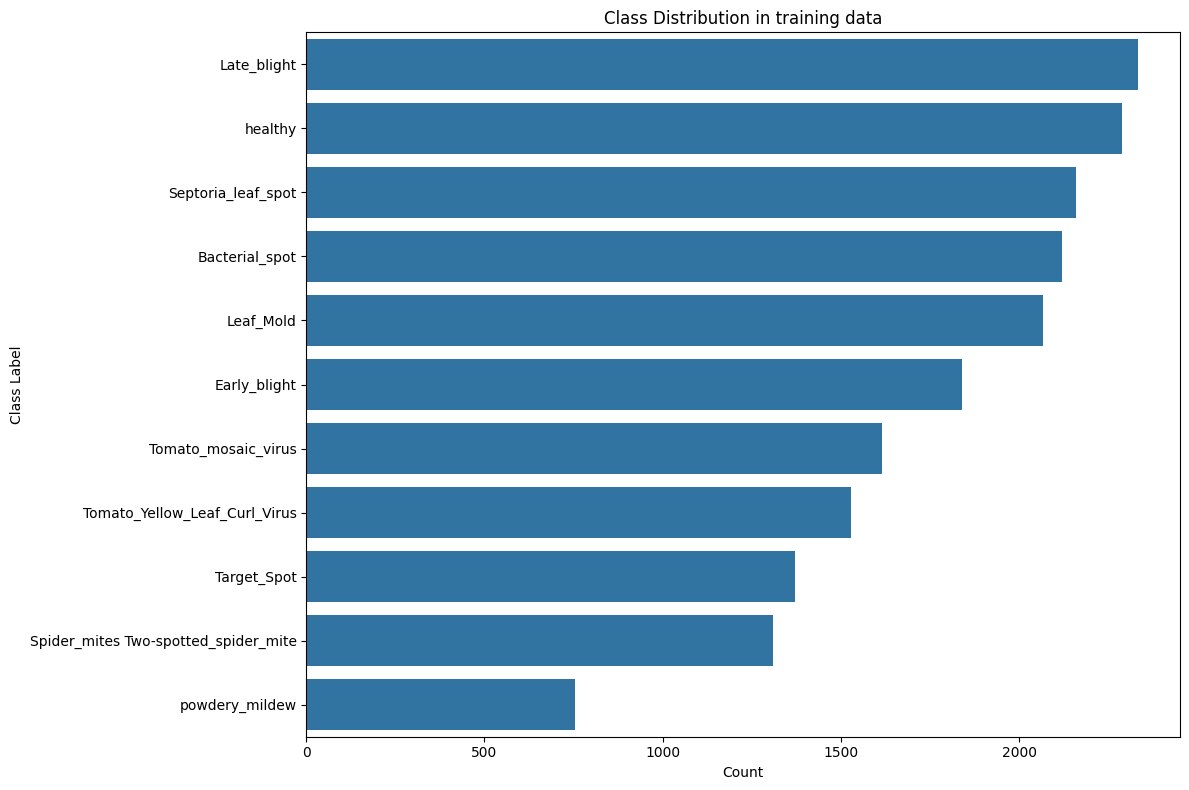

In [23]:
plt.figure(figsize=(12, 8))
order = train_df['label'].value_counts().index
sns.countplot(data=train_df, y='label', order=order)
plt.title('Class Distribution in training data')
plt.xlabel('Count')
plt.ylabel('Class Label')
plt.tight_layout()
plt.show()

In [24]:
def show_samples(df, num_samples=9):
    if df.empty:
        print("No data to visualize.")
        return
        
    plt.figure(figsize=(15, 12))
    # Sample random images
    sample_df = df.sample(min(num_samples, len(df)))
    
    for i, (_, row) in enumerate(sample_df.iterrows()):
        try:
            img = Image.open(row['path'])
            plt.subplot(3, 3, i + 1)
            plt.imshow(img)
            plt.title(row['label'])
            plt.axis('off')
        except Exception as e:
            print(f"Error loading image {row['path']}: {e}")
            
    plt.tight_layout()
    plt.show()

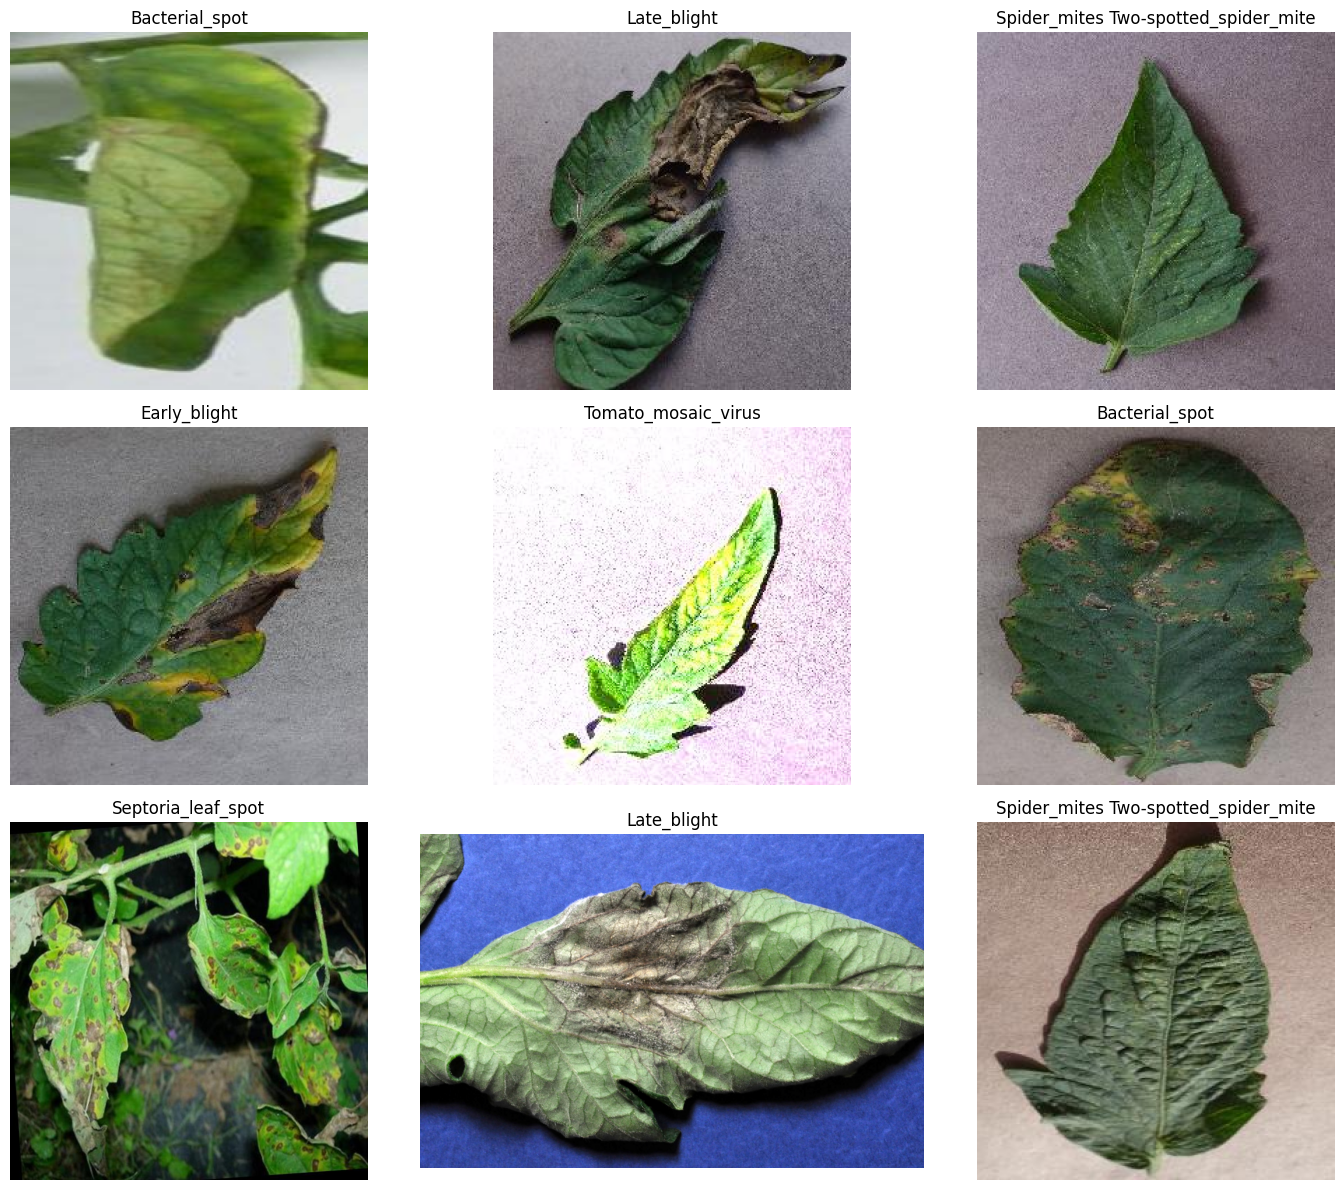

In [26]:
train_samples = show_samples(train_df)

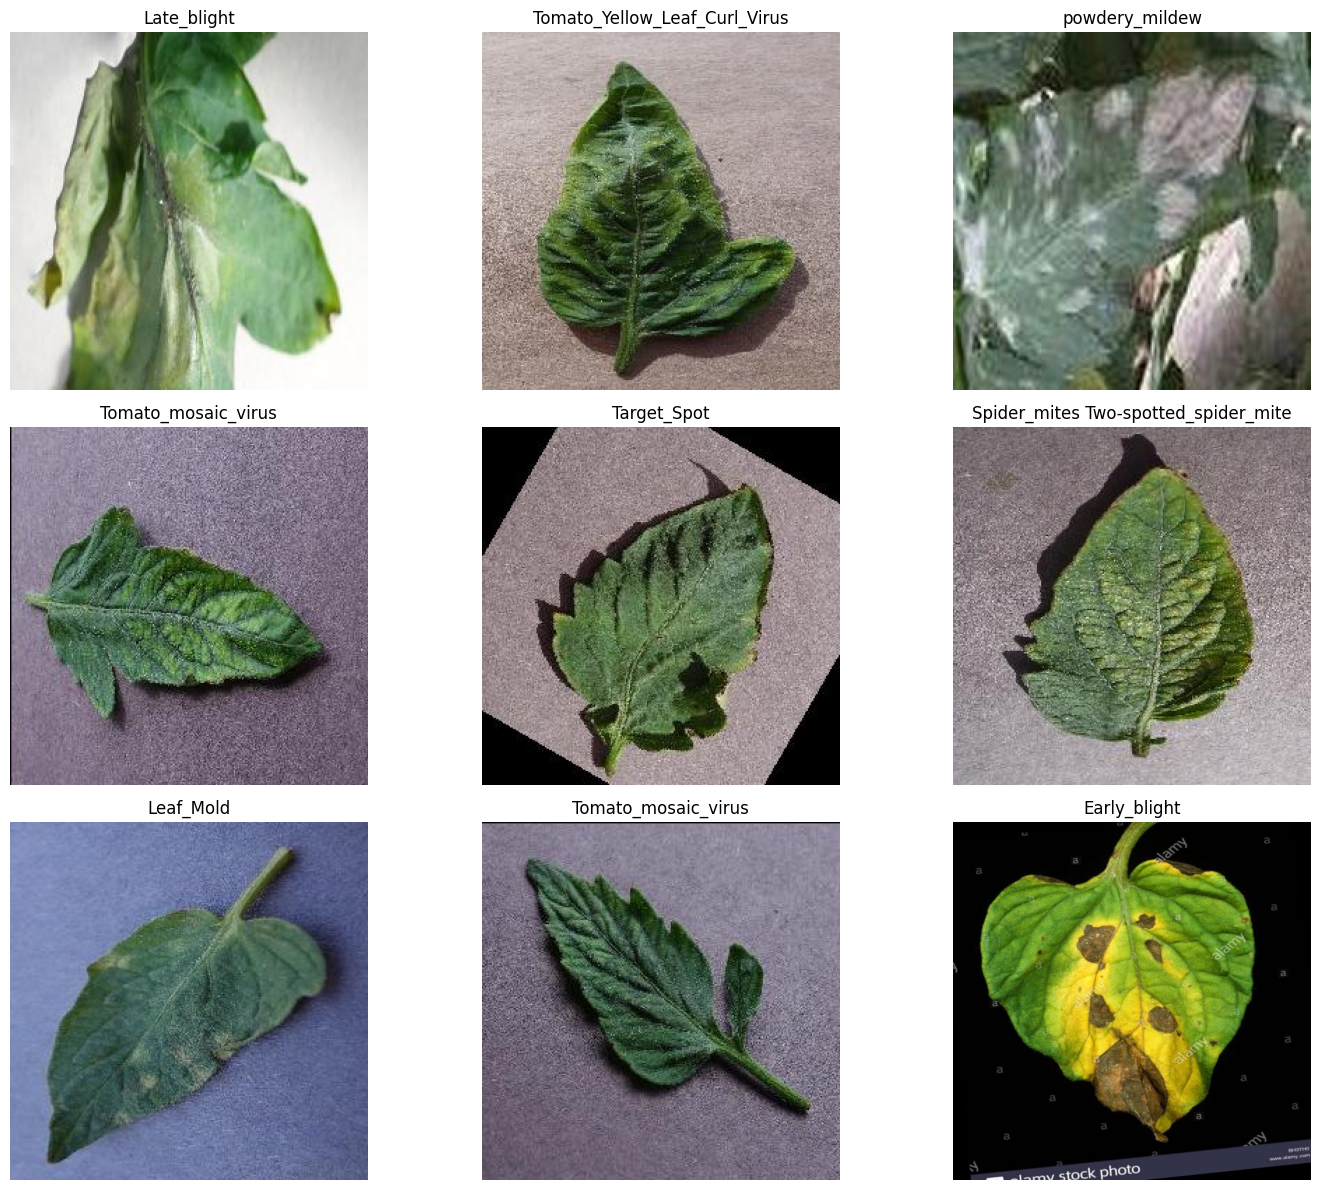

In [28]:
valid_samples = show_samples(valid_df)

In [39]:
def get_image_size_distribution(df, path_col, name="Train"):
    widths = []
    heights = []

    for path in df[path_col]:
        try:
            with Image.open(path) as img:
                widths.append(img.width)
                heights.append(img.height)
        except:
            pass

    data = pd.DataFrame({'Width': widths, 'Height': heights})
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 6))
    
    sns.boxenplot(data=data[['Width']], ax=axes[0])
    axes[0].set_title('Image Width Distribution')
    axes[0].set_ylabel("Width in pixels")

    sns.boxenplot(data=data[['Height']], ax=axes[1])
    axes[1].set_title('Image Height Distribution')
    axes[1].set_ylabel("Height in pixels")
    
    plt.tight_layout()
    plt.show()

    print(f"{name} dataset - Average Width in pixels: {np.mean(widths):.2f}")
    print(f"{name} dataset - Median Width in pixels: {np.median(widths):.2f}")
    print(f"{name} dataset - Average Height in pixels: {np.mean(heights):.2f}")
    print(f"{name} dataset - Median Height in pixels: {np.median(heights):.2f}")
    print(f"{name} dataset - Min Dimensions in pixels: {min(widths)}x{min(heights)}")
    print(f"{name} dataset - Max Dimensions in pixels: {max(widths)}x{max(heights)}")

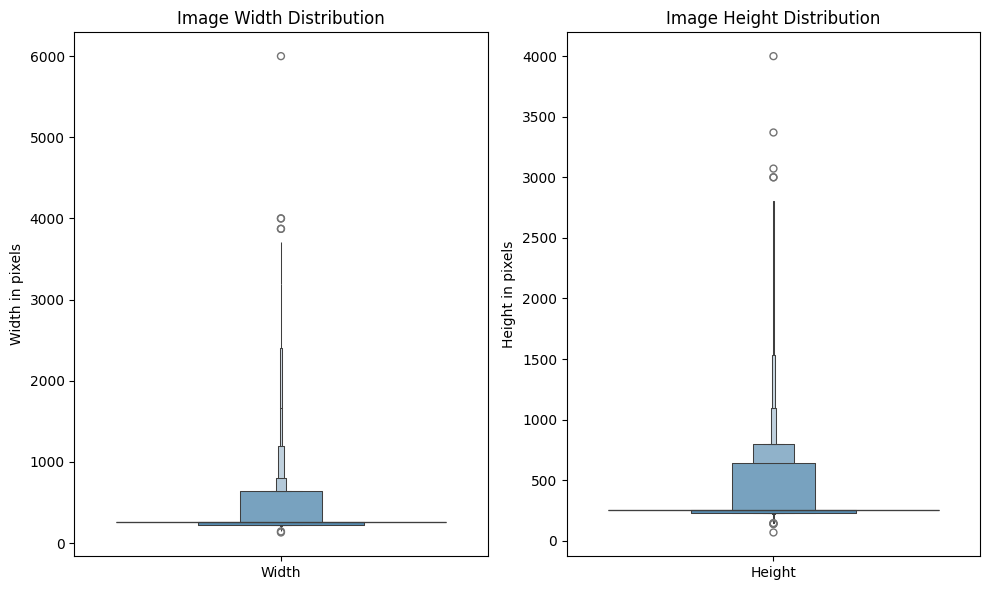

Train dataset - Average Width in pixels: 292.72
Train dataset - Median Width in pixels: 256.00
Train dataset - Average Height in pixels: 301.86
Train dataset - Median Height in pixels: 256.00
Train dataset - Min Dimensions in pixels: 130x69
Train dataset - Max Dimensions in pixels: 6000x4000


In [40]:
get_image_size_distribution(df=train_df, path_col="path", name="Train")

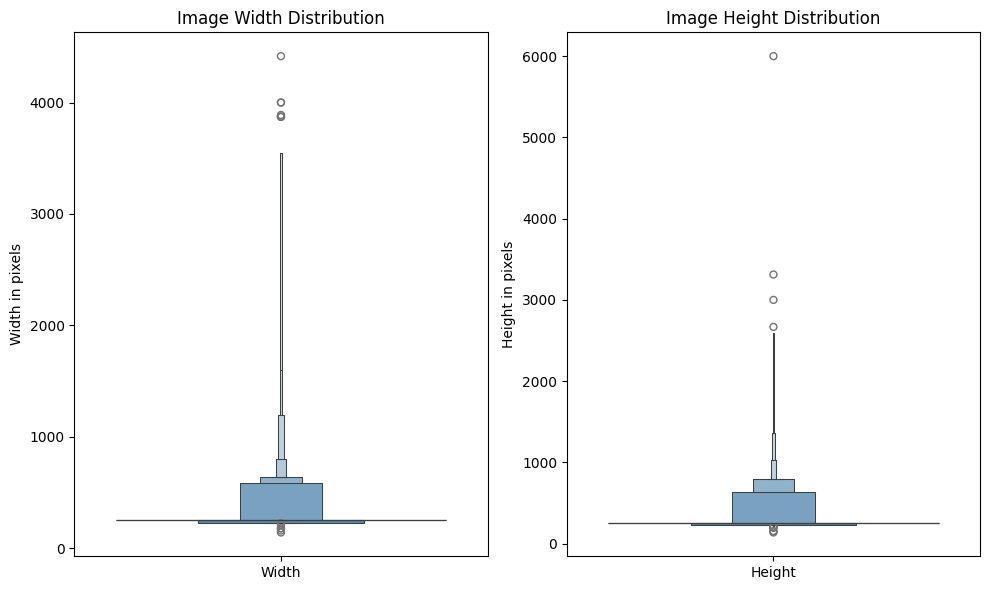

Validation dataset - Average Width in pixels: 291.90
Validation dataset - Median Width in pixels: 256.00
Validation dataset - Average Height in pixels: 300.55
Validation dataset - Median Height in pixels: 256.00
Validation dataset - Min Dimensions in pixels: 142x137
Validation dataset - Max Dimensions in pixels: 4416x6000


In [41]:
get_image_size_distribution(df=valid_df, path_col="path", name="Validation")

# Custom dataset creation

In [46]:
class ImageDataset(Dataset):
  def __init__(self, df, label_to_id, transform=None):
    self.df = df
    self.label_to_id = label_to_id
    self.transform = transform

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    img_path = self.df.iloc[idx]["path"]
    image = Image.open(img_path).convert("RGB")
    label = self.label_to_id[self.df.iloc[idx]["label"]]

    if self.transform:
      image = self.transform(image)

    return image, label

In [52]:
transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor(),
    transforms.Normalize(mean= [0.485, 0.456, 0.406], std= [0.229, 0.224, 0.225])]
)

In [53]:
train_image_dataset = ImageDataset(df=train_df, label_to_id=train_and_validation_classes, transform=transform)
validation_image_dataset = ImageDataset(df=valid_df, label_to_id=train_and_validation_classes, transform=transform)
test_image_dataset = ImageDataset(df=test_df, label_to_id=test_classes, transform=transform)


In [54]:
train_image_loader = DataLoader(dataset=train_image_dataset, batch_size=32, shuffle=True)
validation_image_loader = DataLoader(dataset=validation_image_dataset, batch_size=32, shuffle=True)
test_image_loader = DataLoader(dataset=test_image_dataset, batch_size=32, shuffle=True)

In [55]:
for img, id in train_image_loader:
  print(img.shape, id.shape)
  break

torch.Size([32, 3, 256, 256]) torch.Size([32])


In [56]:
train_dict = {v:k for k, v in train_image_dataset.label_to_id.items()}
test_dict = {v:k for k, v in test_image_dataset.label_to_id.items()}
validation_dict = {v:k for k, v in validation_image_dataset.label_to_id.items()}

torch.Size([32, 3, 256, 256]) torch.Size([32])
(3, 256, 256)
Septoria_leaf_spot
(256, 256, 3)
4


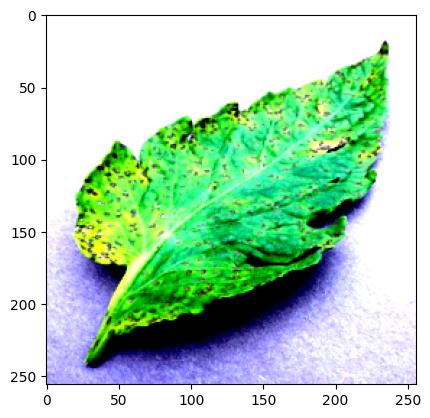

In [58]:
for images, labels in train_image_loader:
  print(images.shape, labels.shape)
  img = images[0].numpy()
  print(img.shape)
  label = labels[0].item()
  print(train_dict[label])
  img = np.transpose(img, (1,2,0))
  print(img.shape)
  print(label)
  plt.imshow(img)
  break

In [59]:
class CustomCnnModel(nn.Module):
  def __init__(self,input_dim, num_classes):
    super(CustomCnnModel, self).__init__()
    self.input_dim = input_dim
    self.num_classes = num_classes

    self.conv_layers = nn.Sequential(
        # C1
        nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
        # 128x128x3 --> 3x3x3x32 --> wxhx32
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        # C2
        nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        # C3
        nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        # C4
        nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )

    self._to_linear = None
    self._get_conv_output(self.input_dim)

    self.fc_layers = nn.Sequential(
        nn.Linear(self._to_linear, 512),
        nn.ReLU(),
        # nn.Dropout(0.2)
        nn.Linear(512, 128),
        nn.ReLU(),
        nn.Linear(128, self.num_classes),
    )

    # 256 x 12 x 12

  def _get_conv_output(self, input_dim=128):
    with torch.no_grad():
      dummy_input = torch.zeros(1,3, input_dim, input_dim)
      output = self.conv_layers(dummy_input)
      self._to_linear = output.view(1, -1).size(1)

  def forward(self,x):
    x = self.conv_layers(x)
    x = x.view(x.size(0), -1)
    x = self.fc_layers(x)
    return x

In [60]:
num_train_classes = len(train_and_validation_classes)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CustomCnnModel(input_dim=256, num_classes=num_train_classes).to(device)

In [61]:
print(device)

cuda


In [62]:
print(summary(model, (3,256,256)))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 256, 256]             896
       BatchNorm2d-2         [-1, 32, 256, 256]              64
              ReLU-3         [-1, 32, 256, 256]               0
         MaxPool2d-4         [-1, 32, 128, 128]               0
            Conv2d-5         [-1, 64, 128, 128]          18,496
       BatchNorm2d-6         [-1, 64, 128, 128]             128
              ReLU-7         [-1, 64, 128, 128]               0
         MaxPool2d-8           [-1, 64, 64, 64]               0
            Conv2d-9          [-1, 128, 64, 64]          73,856
      BatchNorm2d-10          [-1, 128, 64, 64]             256
             ReLU-11          [-1, 128, 64, 64]               0
        MaxPool2d-12          [-1, 128, 32, 32]               0
           Conv2d-13          [-1, 256, 32, 32]         295,168
      BatchNorm2d-14          [-1, 256,

In [63]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)

In [64]:
len(train_image_loader)

606

In [ ]:
# Training loop
epochs = 40
for epoch in range(epochs):
  model.train()
  running_loss = 0.0
  for images, labels in train_image_loader:
    images,labels = images.to(device), labels.to(device).long()
    optimizer.zero_grad()
    outputs = model(images)
    # [x, 3, 128, 128]

    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    running_loss+=loss.item()
  print(f"Epoch {epoch+1}/{epochs}, Loss : {running_loss/len(train_image_loader)}")
  
torch.save(model.state_dict(), "models/cnn_model_40.pth")

Epoch 1/40, Loss : 1.50930518934829
Epoch 2/40, Loss : 0.712109623569073
Epoch 3/40, Loss : 0.5665211267892284
Epoch 4/40, Loss : 0.4873196921824622
Epoch 5/40, Loss : 0.4093408271449037
Epoch 6/40, Loss : 0.3513101667362471
Epoch 7/40, Loss : 0.3083276225456802
Epoch 8/40, Loss : 0.2659143731704984
Epoch 9/40, Loss : 0.20664466137109516
Epoch 10/40, Loss : 0.16896766814996456
Epoch 11/40, Loss : 0.1595434771870684
Epoch 12/40, Loss : 0.12469679701046729
Epoch 13/40, Loss : 0.10942753878800143
Epoch 14/40, Loss : 0.09919726601210131
Epoch 15/40, Loss : 0.09189613781274464
Epoch 16/40, Loss : 0.08525592809888417
Epoch 17/40, Loss : 0.07953925003214926
Epoch 18/40, Loss : 0.06233333586249309
Epoch 19/40, Loss : 0.06367761518439131
Epoch 20/40, Loss : 0.05743945588233071
Epoch 21/40, Loss : 0.0599227449466006
Epoch 22/40, Loss : 0.06173617956445392
Epoch 23/40, Loss : 0.030439407296821944
Epoch 24/40, Loss : 0.043713189956665385
Epoch 25/40, Loss : 0.04791767061717542
Epoch 26/40, Loss : 

In [65]:
model = CustomCnnModel(input_dim=256, num_classes=num_train_classes).to(device=device)

model.load_state_dict(torch.load("cnn_model_40.pth"))
print(model.state_dict())

OrderedDict({'conv_layers.0.weight': tensor([[[[ 1.0946e-01, -6.1766e-02,  1.5846e-01],
          [ 1.6367e-01,  2.7637e-02,  2.8203e-02],
          [ 3.9077e-02,  4.1336e-02,  1.1700e-01]],

         [[-3.3796e-01,  5.0035e-02, -3.7787e-01],
          [-6.8755e-02, -2.4094e-01, -3.2874e-01],
          [-1.2078e-01, -1.7266e-01, -3.1138e-01]],

         [[ 1.4409e-01,  3.2420e-01, -5.9518e-04],
          [ 2.0992e-01,  1.2555e-01,  1.3717e-01],
          [ 1.6792e-02, -2.0896e-02, -4.4089e-02]]],


        [[[ 1.5935e-01,  2.9220e-01,  2.1118e-01],
          [ 1.0225e-01,  2.5279e-01,  2.0738e-01],
          [ 5.6812e-02,  5.0038e-02,  2.8193e-03]],

         [[-8.3700e-02, -2.6816e-01, -2.3211e-01],
          [-1.7857e-01, -2.8910e-01, -1.9235e-01],
          [-6.7955e-03, -1.2269e-01, -1.6288e-01]],

         [[ 1.5483e-01,  1.8568e-01,  1.2940e-01],
          [ 2.9395e-01,  2.2560e-01,  6.8507e-02],
          [ 2.7282e-02,  1.6038e-01,  2.0171e-01]]],


        [[[ 6.8220e-02,  1.26

In [66]:
print(model)

CustomCnnModel(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_sta

In [68]:
for images, labels in validation_image_loader:
  print(labels.shape)
  break

torch.Size([32])


In [69]:
# Evaluate model

model.eval()
correct = 0
total = 0

with torch.no_grad():
  for images, labels in validation_image_loader:
    images,labels = images.to(device), labels.to(device)
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

print(f"Test accuracy is :{100* correct / total:.2f}%")

Test accuracy is :24.77%


# VGG16 pretrained model

In [32]:
vgg_model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
vgg_model.eval()

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [33]:
print(vgg_model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [34]:
print(vgg_model.features)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (17): Conv2d(256, 512, kernel_si

In [35]:
for name, layer in vgg_model.named_children():
    print(f"Block: {name}")
    print(layer)
    print("-" * 20)

Block: features
Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (17): Conv2d(256

In [36]:
for param in vgg_model.parameters():
    param.requires_grad = False

In [37]:
vgg_model.classifier[6].in_features

4096

In [38]:
vgg_num_classes = 11
vgg_in_features = vgg_model.classifier[6].in_features

vgg_in_features

4096

In [39]:
vgg_model.classifier[6] = nn.Linear(vgg_in_features, vgg_num_classes)

In [40]:
vgg_model.to(device)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [41]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    train_losses, val_losses, val_accuracies = [], [], []
    best_accuracy = 0.0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_losses.append(running_loss / len(train_loader))

        model.eval()
        val_loss = 0.0
        correct, total = 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()

        val_losses.append(val_loss / len(val_loader))
        val_accuracy = correct / total
        val_accuracies.append(val_accuracy)

        print(f'Epoch {epoch+1}/{epochs}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}, Val Accuracy: {val_accuracies[-1]:.4f}')

        if val_accuracy > best_accuracy:
            best_accuracy = val_accuracy
            torch.save(model.state_dict(), 'best_vgg_model.pth')
            print("Model checkpoint saved")

    return train_losses, val_losses, val_accuracies

In [52]:
def my_train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=10, save_path="best_model.pth"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    mlflow.log_params({"epochs": epochs})
    
    train_acc_metric = Accuracy(task="multiclass", num_classes=11).to(device)
    val_acc_metric = Accuracy(task="multiclass", num_classes=11).to(device)

    train_loss_metric = MeanMetric().to(device)
    val_loss_metric = MeanMetric().to(device)

    history = {"train_loss":[], "val_loss":[], "val_acc":[]}
    best_accuracy = 0.0
    best_model_weights = copy.deepcopy(model.state_dict())

    train_bar = tqdm(range(epochs), desc="Total Progress", leave=True)
    for epoch in train_bar:
        print(f"Epoch {epoch + 1}/{epochs}")
        print("-" * 10)
    
        model.train()
        
        for images, labels in tqdm(train_loader, desc="Training", leave=False):
            images = images.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss_metric.update(loss)
            train_acc_metric.update(outputs, labels)

            train_bar.set_postfix(loss=loss.item())

        epoch_train_loss = train_loss_metric.compute()
        epoch_train_acc = train_acc_metric.compute()
        train_loss_metric.reset()
        train_acc_metric.reset()

        model.eval()
        
        val_bar = tqdm(val_loader, desc="Validation", leave=False)

        with torch.inference_mode():
            for images, labels in val_bar:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss_metric.update(loss)
                val_acc_metric.update(outputs, labels)

            epoch_val_loss = val_loss_metric.compute()
            epoch_val_acc = val_acc_metric.compute()
            val_loss_metric.reset()
            val_acc_metric.reset()

            history['train_loss'].append(epoch_train_loss.item())
            history['val_loss'].append(epoch_val_loss.item())
            history['val_acc'].append(epoch_val_acc.item())
            
            mlflow.log_metrics({
                "train_loss": epoch_train_loss.item(),
                "val_loss": epoch_val_loss.item(),
                "val_acc": epoch_val_acc.item()
                },
                step=epoch)

        
            if scheduler:
                scheduler.step()

            print(f'Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}')
 
            # --- Checkpointing ---
            if epoch_val_acc > best_accuracy:
                best_accuracy = epoch_val_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                torch.save(model.state_dict(), save_path)
                print(f"--> New Best Model Saved (Acc: {best_accuracy:.4f})")

        print(f'Training complete. Best Validation Accuracy: {best_accuracy:.4f}')
        model.load_state_dict(best_model_wts)
        
    mlflow.pytorch.log_model(model, name="MLflow_tracked_VGG")
    
    return model, history

    

In [48]:
optimizer = optim.Adam(vgg_model.parameters(),lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)
criterion = nn.CrossEntropyLoss()


In [58]:
train_losses, val_losses, val_accuracies = train_model(vgg_model, train_image_loader, test_image_loader, criterion, optimizer, epochs=20)

Epoch 1/20, Train Loss: 0.9084, Val Loss: 0.6832, Val Accuracy: 0.7747
Model checkpoint saved
Epoch 2/20, Train Loss: 0.8866, Val Loss: 0.6747, Val Accuracy: 0.7778
Model checkpoint saved
Epoch 3/20, Train Loss: 0.8797, Val Loss: 0.6531, Val Accuracy: 0.7806
Model checkpoint saved
Epoch 4/20, Train Loss: 0.8762, Val Loss: 0.6505, Val Accuracy: 0.7868
Model checkpoint saved
Epoch 5/20, Train Loss: 0.8683, Val Loss: 0.6207, Val Accuracy: 0.7968
Model checkpoint saved
Epoch 6/20, Train Loss: 0.8577, Val Loss: 0.6009, Val Accuracy: 0.8060
Model checkpoint saved
Epoch 7/20, Train Loss: 0.8486, Val Loss: 0.5882, Val Accuracy: 0.8066
Model checkpoint saved
Epoch 8/20, Train Loss: 0.8425, Val Loss: 0.6247, Val Accuracy: 0.7866
Epoch 9/20, Train Loss: 0.8528, Val Loss: 0.6155, Val Accuracy: 0.7985
Epoch 10/20, Train Loss: 0.8432, Val Loss: 0.5741, Val Accuracy: 0.8126
Model checkpoint saved
Epoch 11/20, Train Loss: 0.8368, Val Loss: 0.5994, Val Accuracy: 0.8016
Epoch 12/20, Train Loss: 0.8458, 

In [56]:
summary(vgg_model, (3, 256, 256))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 256, 256]           1,792
              ReLU-2         [-1, 64, 256, 256]               0
            Conv2d-3         [-1, 64, 256, 256]          36,928
              ReLU-4         [-1, 64, 256, 256]               0
         MaxPool2d-5         [-1, 64, 128, 128]               0
            Conv2d-6        [-1, 128, 128, 128]          73,856
              ReLU-7        [-1, 128, 128, 128]               0
            Conv2d-8        [-1, 128, 128, 128]         147,584
              ReLU-9        [-1, 128, 128, 128]               0
        MaxPool2d-10          [-1, 128, 64, 64]               0
           Conv2d-11          [-1, 256, 64, 64]         295,168
             ReLU-12          [-1, 256, 64, 64]               0
           Conv2d-13          [-1, 256, 64, 64]         590,080
             ReLU-14          [-1, 256,

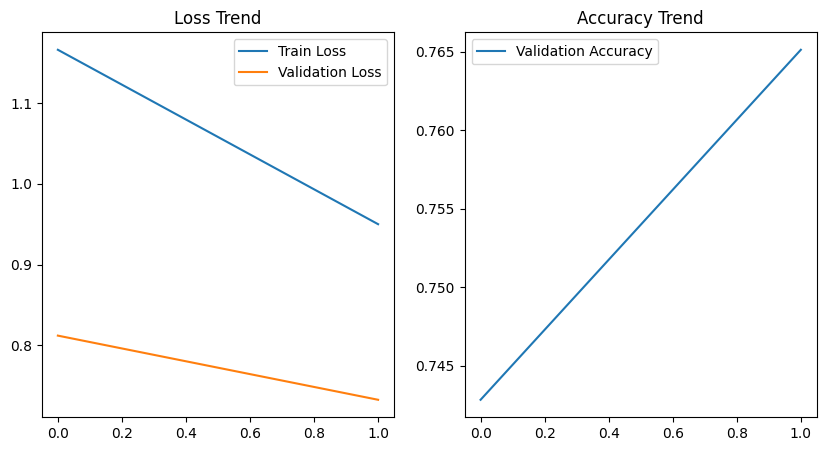

In [57]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Loss plot
ax[0].plot(train_losses, label="Train Loss")
ax[0].plot(val_losses, label="Validation Loss")
ax[0].set_title("Loss Trend")
ax[0].legend()

# Accuracy plot
ax[1].plot(val_accuracies, label="Validation Accuracy")
ax[1].set_title("Accuracy Trend")
ax[1].legend()

plt.show()

In [49]:
mlflow.set_experiment("Deep Learning Experiment")

2026/01/29 18:08:44 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/01/29 18:08:44 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/01/29 18:08:44 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/01/29 18:08:44 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints
2026/01/29 18:08:44 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults
2026/01/29 18:08:44 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments
2026/01/29 18:08:44 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/01/29 18:08:44 INFO mlflow.store.db.utils: Updating database tables
2026/01/29 18:08:44 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/01/29 18:08:44 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026/01/29 18:08:44 INFO alembic.runtime.migration: Running upgrade  -> 451aebb31d03, add metric step
2026/01/29 18:0

<Experiment: artifact_location='file:d:/Projects/disease_detection_project/mlruns/1', creation_time=1769706525256, experiment_id='1', last_update_time=1769706525256, lifecycle_stage='active', name='Deep Learning Experiment', tags={}>

In [53]:
with mlflow.start_run():
    model, history = my_train_model(vgg_model, train_image_loader, test_image_loader, criterion, optimizer, scheduler, epochs=2, save_path="best_custom_model.pth")

Total Progress:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1/2
----------


Total Progress:   0%|          | 0/2 [01:26<?, ?it/s, loss=0.799]

Train Loss: 0.9177 | Val Loss: 0.6865 | Val Acc: 0.7739


Total Progress:  50%|█████     | 1/2 [01:55<01:55, 115.36s/it, loss=0.799]

...

Total Progress:  50%|█████     | 1/2 [03:21<01:55, 115.36s/it, loss=0.666]

Train Loss: 0.8901 | Val Loss: 0.6817 | Val Acc: 0.7753


Total Progress: 100%|██████████| 2/2 [03:50<00:00, 115.01s/it, loss=0.666]
2026/01/29 18:19:41 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


--> New Best Model Saved (Acc: 0.7753)
Training complete. Best Validation Accuracy: 0.7753


2026/01/29 18:19:41 WARNING mlflow.utils.requirements_utils: Found torch version (2.9.1+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.9.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/01/29 18:19:49 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.24.1+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torchvision==0.24.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


In [46]:
history

{'train_loss': [1.1695306301116943],
 'val_loss': [0.8000158071517944],
 'val_acc': [0.7488782405853271]}